Bloque 1. Librerías

In [5]:
# Importamos Pandas para manipular nuestra base de datos.
import pandas as pd

# Importamos NumPy para trabajar con arreglos y operaciones numéricas.
import numpy as np

# Importamos Matplotlib para crear gráficas (nuestros mapas).
import matplotlib.pyplot as plt

# Importamos el algoritmo K-Means.
from sklearn.cluster import KMeans

# Importamos el escalador para normalizar variables con diferentes unidades.
from sklearn.preprocessing import StandardScaler

# Importamos métricas de evaluación de clustering y utilidad de muestreo.
from sklearn.metrics import silhouette_score
from sklearn.utils import resample

In [2]:
# %%
ruta = "us_congestion_2016_2022_sample_2m.csv"

df = pd.read_csv(ruta)

print("Shape original:", df.shape)
df.head()

Shape original: (2000000, 30)


,ID,Severity,Start_Lat,Start_Lng,StartTime,EndTime,Distance(mi),DelayFromTypicalTraffic(mins),DelayFromFreeFlowSpeed(mins),Congestion_Speed,...,Temperature(F),WindChill(F),Humidity(%),Pressure(in),Visibility(mi),WindDir,WindSpeed(mph),Precipitation(in),Weather_Event,Weather_Conditions
0,C-14344128,2,39.191032,-120.819740,2016-12-20T19:19:00.000-05:00,2016-12-20T19:33:47.000-05:00,1.40,2.58,2.60,Moderate,...,54.0,NaN,30.0,30.15,10.0,North,3.5,NaN,NaN,Clear
1,C-32285069,0,41.736015,-87.721565,2018-11-16T17:18:00.000-05:00,2018-11-16T18:08:28.000-05:00,0.73,0.42,1.00,Slow,...,39.0,31.8,70.0,30.06,10.0,West,11.5,NaN,NaN,Overcast
2,C-14213642,0,32.519043,-93.741096,2021-02-18T20:32:00.000-05:00,2021-02-18T21:21:32.000-05:00,1.80,1.00,2.00,Moderate,...,30.0,30.0,79.0,30.20,10.0,WNW,3.0,0.00,NaN,Fair
3,C-29674072,0,40.730564,-74.001709,2020-11-13T08:06:00.000-05:00,2020-11-13T08:48:22.000-05:00,1.42,1.00,2.00,Slow,...,48.0,48.0,93.0,29.92,1.0,VAR,3.0,0.04,NaN,Light Rain
4,C-24044478,1,33.758331,-118.238533,2017-08-24T09:54:00.000-04:00,2017-08-24T11:13:19.000-04:00,2.60,4.90,6.92,Slow,...,66.9,NaN,79.0,29.89,9.0,Calm,NaN,NaN,NaN,Overcast


In [ ]:
# 1. Cargamos todo el dataset original (puede tardar unos segundos)
df_completo = pd.read_csv(ruta)

# 2. Extraemos una muestra representativa de 100,000 registros
df_muestra = resample(df_completo, n_samples=2000000, random_state=42)

# 3. Seleccionamos solo las variables que usaremos para el agrupamiento (Dónde y Qué tan grave)
columnas_kmeans = ['Start_Lng', 'Start_Lat', 'DelayFromTypicalTraffic(mins)']
X_raw = df_muestra[columnas_kmeans].copy()

# Limpiamos filas que no tengan información en estas columnas
X_raw = X_raw.dropna()

# 4. Escalamos los datos (CRÍTICO para K-Means con datos reales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Shape original del dataset:", df_completo.shape)
print("Shape de los datos muestreados y limpios para K-Means:", X_raw.shape)
print("\nPrimeras 5 observaciones escaladas:")
print(X_scaled[:5])

Shape original del dataset: (2000000, 30)
Shape de los datos muestreados y limpios para K-Means: (2000000, 3)

Primeras 5 observaciones escaladas:
[[-1.66153136  0.38888257 -0.05784367]
 [ 0.2710222   0.88092586 -0.59047809]
 [-0.08044932 -0.90107002 -0.44745588]
 [ 1.07210433  0.68653344 -0.44745588]
 [-1.51081849 -0.66146789  0.5142452 ]]


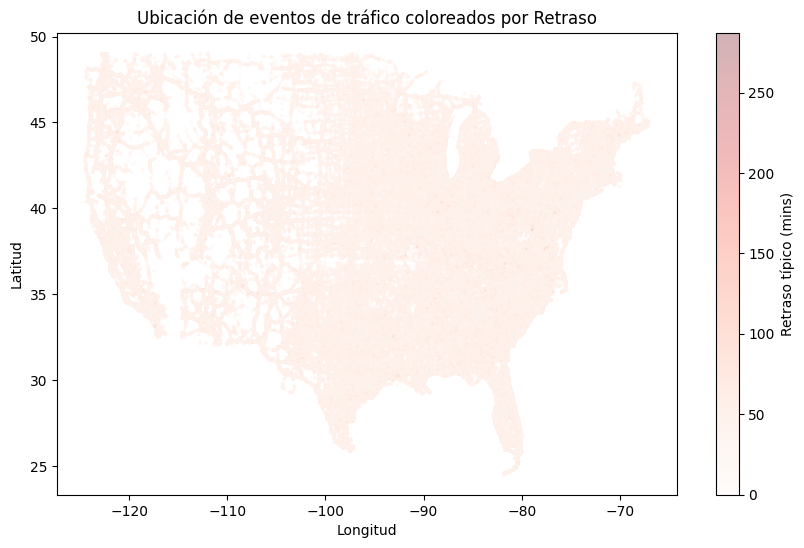

In [23]:
# Creamos una figura y un sistema de ejes.
_, ax = plt.subplots(figsize=(10, 6))

# Dibujamos los datos usando la longitud en X y la latitud en Y.
# Usamos un tamaño de punto (s) muy pequeño y transparencia (alpha) para ver la densidad.
scatter = ax.scatter(
    X_raw['Start_Lng'], 
    X_raw['Start_Lat'], 
    c=X_raw['DelayFromTypicalTraffic(mins)'], # Color según el retraso
    cmap="Reds",        # Paleta de colores (rojo = más retraso)
    alpha=0.3,          # Transparencia
    s=2                 # Tamaño del punto
)

# Agregamos una barra de color para entender la escala de retraso
plt.colorbar(scatter, label='Retraso típico (mins)')

# Agregamos un título y etiquetas a la gráfica.
ax.set_title("Ubicación de eventos de tráfico coloreados por Retraso")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")

# Mostramos la figura.
plt.show()

In [24]:
# Definimos un número inicial de clusters (por ejemplo, 5 tipos de eventos/zonas)
k = 5

# Creamos el modelo K-Means.
kmeans = KMeans(
    n_clusters=k,       
    init="k-means++",   
    n_init=10,          
    random_state=42     
)

# Entrenamos el modelo con los datos ESCALADOS.
kmeans.fit(X_scaled)

# Guardamos la etiqueta de cluster asignada a cada evento.
clusters = kmeans.labels_

# Los centroides están escalados, así que los "des-escalamos" para entenderlos en la vida real.
centroides_reales = scaler.inverse_transform(kmeans.cluster_centers_)

print(f"Primeras 10 etiquetas predichas (de 0 a {k-1}):")
print(clusters[:10])

# Formateamos la impresión de los centroides para que se entienda
print("\nPerfil de los Centroides encontrados (Lng, Lat, Delay):")
df_centroides = pd.DataFrame(centroides_reales, columns=columnas_kmeans)
print(df_centroides.round(2))

Primeras 10 etiquetas predichas (de 0 a 4):
[1 4 3 4 1 4 4 4 1 1]

Perfil de los Centroides encontrados (Lng, Lat, Delay):
   Start_Lng  Start_Lat  DelayFromTypicalTraffic(mins)
0    -111.53      43.96                           2.91
1    -117.98      35.18                           1.88
2     -90.89      37.42                          17.10
3     -88.46      30.67                           2.36
4     -78.83      40.57                           2.23


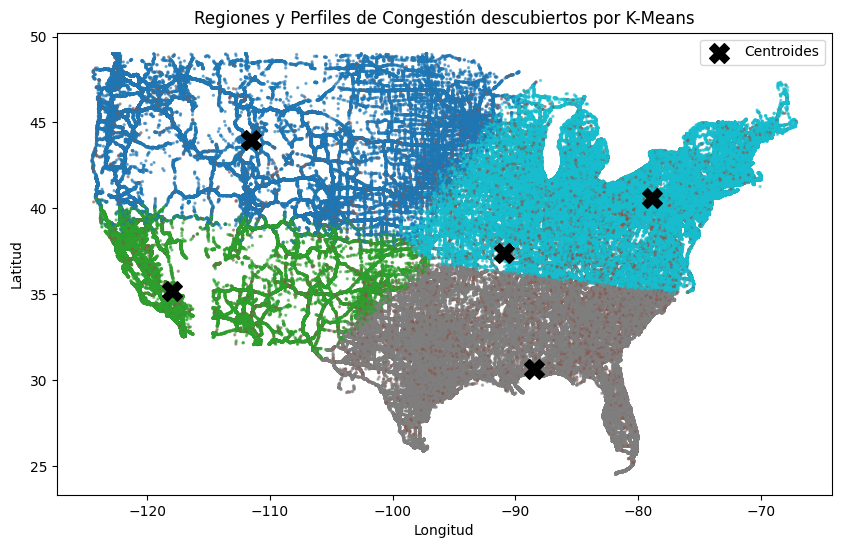

In [25]:
# Creamos una figura para mostrar el resultado del clustering.
_, ax = plt.subplots(figsize=(10, 6))

# Dibujamos los puntos coloreados según el cluster asignado.
ax.scatter(
    X_raw['Start_Lng'],            
    X_raw['Start_Lat'],            
    c=clusters,         
    cmap="tab10",       # Paleta de colores categórica para diferenciar clusters
    alpha=0.5,
    s=2
)

# Dibujamos los centroides reales sobre el mapa
ax.scatter(
    centroides_reales[:, 0],   # Longitud
    centroides_reales[:, 1],   # Latitud
    c="black",                 # Color negro para resaltar
    s=200,              
    marker="X",         
    label="Centroides"  
)

ax.set_title("Regiones y Perfiles de Congestión descubiertos por K-Means")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend()
plt.show()

In [26]:
# Calculamos la inercia del modelo.
inercia = kmeans.inertia_

# Calculamos el índice silhouette en una sub-muestra para que no tome horas.
X_scaled_muestra_sil = resample(X_scaled, n_samples=10000, random_state=42)
clusters_muestra_sil = kmeans.predict(X_scaled_muestra_sil)

silhouette = silhouette_score(X_scaled_muestra_sil, clusters_muestra_sil)

print(f"Inercia del modelo con k={k}: {inercia:,.2f}")
print(f"Silhouette Score (sub-muestra): {silhouette:.4f}")

Inercia del modelo con k=5: 1,827,972.72
Silhouette Score (sub-muestra): 0.4597


Calculando inercias... esto puede tomar un par de minutos.


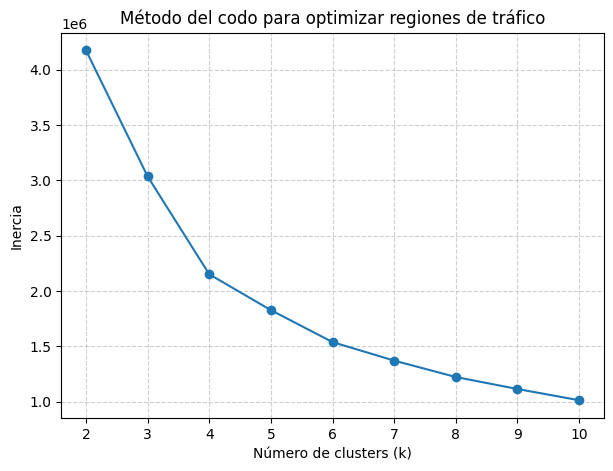

In [27]:
inercias = []
rango_k = range(2, 11) # Probaremos de 2 a 10 clusters

print("Calculando inercias... esto puede tomar un par de minutos.")
for k_val in rango_k:
    model = KMeans(n_clusters=k_val, init="k-means++", n_init=10, random_state=42)
    model.fit(X_scaled) # Siempre usar datos escalados
    inercias.append(model.inertia_)

# Creamos la figura del método del codo.
_, ax = plt.subplots(figsize=(7, 5))
ax.plot(rango_k, inercias, marker="o")
ax.set_title("Método del codo para optimizar regiones de tráfico")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Inercia")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [28]:
# [Longitud, Latitud, Retraso en minutos]
# Punto 1: Ej. Los Angeles con retraso grave (45 min)
# Punto 2: Ej. Nueva York con retraso leve (5 min)
nuevos_eventos = np.array([
    [-118.24, 34.05, 45.0],  
    [-74.00, 40.71, 5.0]     
])

# CRÍTICO: Debemos escalar los nuevos puntos usando el mismo 'scaler' que entrenamos
nuevos_eventos_escalados = scaler.transform(nuevos_eventos)

# Predecimos
pred_nuevos = kmeans.predict(nuevos_eventos_escalados)

print("Coordenadas y retraso de nuevos eventos:")
print(nuevos_eventos)
print(f"\nEstos eventos han sido clasificados en los clusters: {pred_nuevos}")

Coordenadas y retraso de nuevos eventos:
[[-118.24   34.05   45.  ]
 [ -74.     40.71    5.  ]]

Estos eventos han sido clasificados en los clusters: [2 4]


c:\Users\USUARIO\Documents\Semestre9\ML\MachineLearning\Week_4_5\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
